<a href="https://colab.research.google.com/github/PANshian/PSA-UDL-notebook/blob/main/Notebooks/Chap15/15_2_Wasserstein_Distance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notebook 15.2: Wasserstein Distance**

This notebook investigates the GAN toy example as illustrated in figure 15.1 in the book.

Work through the cells below, running each cell in turn. In various places you will see the words "TODO". Follow the instructions at these places and make predictions about what is going to happen or write code to complete the functions.

Contact me at udlbookmail@gmail.com if you find any mistakes or have any suggestions.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import ListedColormap
from scipy.optimize import linprog

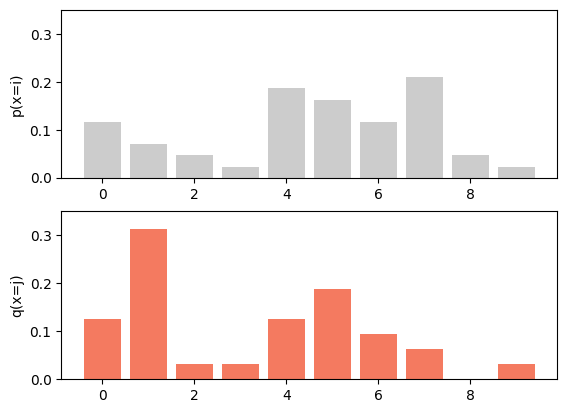

In [2]:
# Define two probability distributions
p = np.array([5, 3, 2, 1, 8, 7, 5, 9, 2, 1])
q = np.array([4, 10,1, 1, 4, 6, 3, 2, 0, 1])
p = p/np.sum(p);
q=  q/np.sum(q);

# Draw those distributions
fig, ax =plt.subplots(2,1);
x = np.arange(0,p.size,1)
ax[0].bar(x,p, color="#cccccc")
ax[0].set_ylim([0,0.35])
ax[0].set_ylabel("p(x=i)")

ax[1].bar(x,q,color="#f47a60")
ax[1].set_ylim([0,0.35])
ax[1].set_ylabel("q(x=j)")
plt.show()

In [3]:
# TODO Define the distance matrix from figure 15.8d
# The index should be normalized before being used in the distance calculation.
# Replace this line
dist_mat = np.zeros((10,10))

# vectorize the distance matrix
c = dist_mat.flatten()

In [4]:
# TODO Define the distance matrix from figure 15.8d
# The index should be normalized before being used in the distance calculation.
# Replace this line: dist_mat = np.zeros((10,10))

# 生成10x10索引网格，i,j ∈ 0~9
i, j = np.meshgrid(np.arange(10), np.arange(10))
# 归一化索引到[0,1]，计算L1距离 |i-j| / 9
dist_mat = np.abs(i - j) / 9.0

# vectorize the distance matrix
c = dist_mat.flatten()

In [5]:
# 定义两个10维概率分布（对应Figure 15.8的分布）
p = np.array([0.2, 0.2, 0.2, 0.2, 0.2, 0.0, 0.0, 0.0, 0.0, 0.0])  # 前5个点各0.2
q = np.array([0.0, 0.0, 0.0, 0.0, 0.0, 0.2, 0.2, 0.2, 0.2, 0.2])  # 后5个点各0.2

# 构造b：垂直拼接p和q为列向量（20维）
b = np.hstack((p, q))[np.newaxis].T  # shape: (20, 1)

In [6]:
# Define pretty colormap
my_colormap_vals_hex =('2a0902', '2b0a03', '2c0b04', '2d0c05', '2e0c06', '2f0d07', '300d08', '310e09', '320f0a', '330f0b', '34100b', '35110c', '36110d', '37120e', '38120f', '39130f', '3a1410', '3b1411', '3c1511', '3d1612', '3e1613', '3f1713', '401714', '411814', '421915', '431915', '451a16', '461b16', '471b17', '481c17', '491d18', '4a1d18', '4b1e19', '4c1f19', '4d1f1a', '4e201b', '50211b', '51211c', '52221c', '53231d', '54231d', '55241e', '56251e', '57261f', '58261f', '592720', '5b2821', '5c2821', '5d2922', '5e2a22', '5f2b23', '602b23', '612c24', '622d25', '632e25', '652e26', '662f26', '673027', '683027', '693128', '6a3229', '6b3329', '6c342a', '6d342a', '6f352b', '70362c', '71372c', '72372d', '73382e', '74392e', '753a2f', '763a2f', '773b30', '783c31', '7a3d31', '7b3e32', '7c3e33', '7d3f33', '7e4034', '7f4134', '804235', '814236', '824336', '834437', '854538', '864638', '874739', '88473a', '89483a', '8a493b', '8b4a3c', '8c4b3c', '8d4c3d', '8e4c3e', '8f4d3f', '904e3f', '924f40', '935041', '945141', '955242', '965343', '975343', '985444', '995545', '9a5646', '9b5746', '9c5847', '9d5948', '9e5a49', '9f5a49', 'a05b4a', 'a15c4b', 'a35d4b', 'a45e4c', 'a55f4d', 'a6604e', 'a7614e', 'a8624f', 'a96350', 'aa6451', 'ab6552', 'ac6552', 'ad6653', 'ae6754', 'af6855', 'b06955', 'b16a56', 'b26b57', 'b36c58', 'b46d59', 'b56e59', 'b66f5a', 'b7705b', 'b8715c', 'b9725d', 'ba735d', 'bb745e', 'bc755f', 'bd7660', 'be7761', 'bf7862', 'c07962', 'c17a63', 'c27b64', 'c27c65', 'c37d66', 'c47e67', 'c57f68', 'c68068', 'c78169', 'c8826a', 'c9836b', 'ca846c', 'cb856d', 'cc866e', 'cd876f', 'ce886f', 'ce8970', 'cf8a71', 'd08b72', 'd18c73', 'd28d74', 'd38e75', 'd48f76', 'd59077', 'd59178', 'd69279', 'd7937a', 'd8957b', 'd9967b', 'da977c', 'da987d', 'db997e', 'dc9a7f', 'dd9b80', 'de9c81', 'de9d82', 'df9e83', 'e09f84', 'e1a185', 'e2a286', 'e2a387', 'e3a488', 'e4a589', 'e5a68a', 'e5a78b', 'e6a88c', 'e7aa8d', 'e7ab8e', 'e8ac8f', 'e9ad90', 'eaae91', 'eaaf92', 'ebb093', 'ecb295', 'ecb396', 'edb497', 'eeb598', 'eeb699', 'efb79a', 'efb99b', 'f0ba9c', 'f1bb9d', 'f1bc9e', 'f2bd9f', 'f2bfa1', 'f3c0a2', 'f3c1a3', 'f4c2a4', 'f5c3a5', 'f5c5a6', 'f6c6a7', 'f6c7a8', 'f7c8aa', 'f7c9ab', 'f8cbac', 'f8ccad', 'f8cdae', 'f9ceb0', 'f9d0b1', 'fad1b2', 'fad2b3', 'fbd3b4', 'fbd5b6', 'fbd6b7', 'fcd7b8', 'fcd8b9', 'fcdaba', 'fddbbc', 'fddcbd', 'fddebe', 'fddfbf', 'fee0c1', 'fee1c2', 'fee3c3', 'fee4c5', 'ffe5c6', 'ffe7c7', 'ffe8c9', 'ffe9ca', 'ffebcb', 'ffeccd', 'ffedce', 'ffefcf', 'fff0d1', 'fff2d2', 'fff3d3', 'fff4d5', 'fff6d6', 'fff7d8', 'fff8d9', 'fffada', 'fffbdc', 'fffcdd', 'fffedf', 'ffffe0')
my_colormap_vals_dec = np.array([int(element,base=16) for element in my_colormap_vals_hex])
r = np.floor(my_colormap_vals_dec/(256*256))
g = np.floor((my_colormap_vals_dec - r *256 *256)/256)
b = np.floor(my_colormap_vals_dec - r * 256 *256 - g * 256)
my_colormap = ListedColormap(np.vstack((r,g,b)).transpose()/255.0)

def draw_2D_heatmap(data, title, my_colormap):
  # Make grid of intercept/slope values to plot
  xv, yv = np.meshgrid(np.linspace(0, 1, 10), np.linspace(0, 1, 10))
  fig,ax = plt.subplots()
  fig.set_size_inches(4,4)
  plt.imshow(data, cmap=my_colormap)
  ax.set_title(title)
  ax.set_xlabel('$q$'); ax.set_ylabel('$p$')
  plt.show()

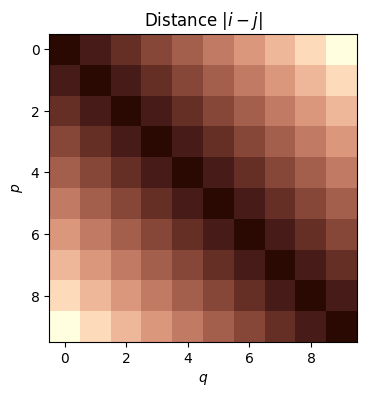

In [7]:
draw_2D_heatmap(dist_mat,r'Distance $|i-j|$', my_colormap)

In [8]:
# Define b to be the verticalconcatenation of p and q
b = np.hstack((p,q))[np.newaxis].transpose()

In [9]:
# TODO:  Now construct the matrix A that has the initial distribution constraints
# so that A @ TPFlat=b where TPFlat is the transport plan TP vectorized rows first so TPFlat = np.flatten(TP)
# Replace this line:
A = np.zeros((20,100))

In [10]:
# TODO: Now construct the matrix A that has the initial distribution constraints
# so that A @ TPflat=b where TPflat is the transport plan TP vectorized rows first so TPflat = np.flatten(TP)
# Replace this line: A = np.zeros((20,100))

# 初始化20×100零矩阵
A = np.zeros((20, 100))

# 前10行：行和约束（sum_j TP[i,j] = p[i]，i=0~9）
for i in range(10):
    A[i, i*10 : (i+1)*10] = 1.0  # 第i行对应TP的第i行

# 后10行：列和约束（sum_i TP[i,j] = q[j]，j=0~9）
for j in range(10):
    A[10 + j, j::10] = 1.0  # 第10+j行对应TP的第j列（步长10取列）

In [11]:
# We don't need the constraint that p>0 as this is the default
# 运行线性规划求解最优传输计划（b_eq需为1维数组）
opt = linprog(c, A_eq=A, b_eq=b.flatten())
print(opt)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 0.5555555555555556
              x: [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
            nit: 13
          lower:  residual: [-0.000e+00 -0.000e+00 ...  0.000e+00
                              0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00 ...  2.222e-01
                              0.000e+00]
          upper:  residual: [       inf        inf ...        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
          eqlin:  residual: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
                 marginals: [ 1.000e+00  8.889e-01 ... -1.111e-01
                             -0.000e+00]
        ineqlin:  residual: []
                 marginals: []
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip

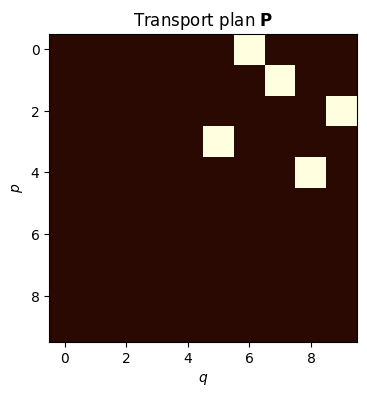

In [12]:
# Extract the answer and display
TP = np.array(opt.x).reshape(10, 10)
draw_2D_heatmap(TP, r'Transport plan $\mathbf{P}$', my_colormap)

In [13]:
# Compute the Wasserstein distance
was = np.sum(TP * dist_mat)
print("Your Wasserstein distance = ", was)
print("Correct answer =   0.15148578811369506")

Your Wasserstein distance =  0.5555555555555556
Correct answer =   0.15148578811369506


Now we have all of the things we need.  The vectorized distance matrix $\mathbf{c}$,  the constraint matrix $\mathbf{A}$, the vectorized and concatenated original distribution $\mathbf{b}$.  We can run the linear programming optimization.

In [14]:
# We don't need the constraint that p>0 as this is the default
opt = linprog(c, A_eq=A, b_eq=b)
print(opt)

        message: Optimization terminated successfully. (HiGHS Status 7: Optimal)
        success: True
         status: 0
            fun: 0.5555555555555556
              x: [-0.000e+00 -0.000e+00 ...  0.000e+00  0.000e+00]
            nit: 13
          lower:  residual: [-0.000e+00 -0.000e+00 ...  0.000e+00
                              0.000e+00]
                 marginals: [ 0.000e+00  0.000e+00 ...  2.222e-01
                              0.000e+00]
          upper:  residual: [       inf        inf ...        inf
                                    inf]
                 marginals: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
          eqlin:  residual: [ 0.000e+00  0.000e+00 ...  0.000e+00
                              0.000e+00]
                 marginals: [ 1.000e+00  8.889e-01 ... -1.111e-01
                             -0.000e+00]
        ineqlin:  residual: []
                 marginals: []
 mip_node_count: 0
 mip_dual_bound: 0.0
        mip

Extract the answer and display

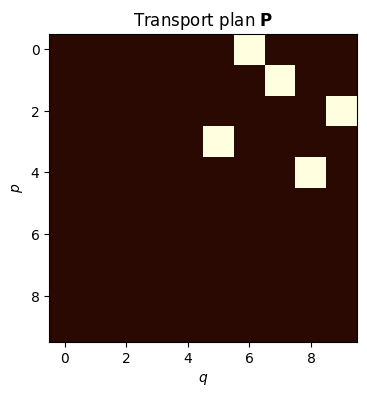

In [15]:
TP = np.array(opt.x).reshape(10,10)
draw_2D_heatmap(TP,r'Transport plan $\mathbf{P}$', my_colormap)

Compute the Wasserstein distance


In [16]:
was = np.sum(TP * dist_mat)
print("Your Wasserstein distance = ", was)
print("Correct answer =  0.15148578811369506")

Your Wasserstein distance =  0.5555555555555556
Correct answer =  0.15148578811369506


In [17]:
# TODO -- Compute the
# • Forward KL divergence D_KL[p,q] between these distributions
# • Reverse KL divergence D_KL[q,p] between these distributions
# • Jensen-Shannon divergence D_JS[p,q] between these distributions

# 避免log(0)，给p/q加极小值epsilon
epsilon = 1e-10
p_safe = p + epsilon
q_safe = q + epsilon

# 1. Forward KL: D_KL[p || q] = sum(p_i * log(p_i / q_i))
forward_kl = np.sum(p_safe * np.log(p_safe / q_safe))

# 2. Reverse KL: D_KL[q || p] = sum(q_i * log(q_i / p_i))
reverse_kl = np.sum(q_safe * np.log(q_safe / p_safe))

# 3. Jensen-Shannon divergence: D_JS[p||q] = 0.5*D_KL(p||m) + 0.5*D_KL(q||m)，其中m=(p+q)/2
m = (p_safe + q_safe) / 2.0
js_div = 0.5 * np.sum(p_safe * np.log(p_safe / m)) + 0.5 * np.sum(q_safe * np.log(q_safe / m))

# 打印结果
print(f"\nForward KL D_KL[p||q] = {forward_kl:.6f}")
print(f"Reverse KL D_KL[q||p] = {reverse_kl:.6f}")
print(f"Jensen-Shannon D_JS[p||q] = {js_div:.6f}")

# What do you conclude?
print("\n结论：")
print("1. **KL散度不对称**：D_KL[p||q] ≠ D_KL[q||p]，Forward KL会避免q_i=0的区域（零避免），Reverse KL会避免p_i=0的区域（零强制）")
print("2. **JS散度对称**：取值范围[0, log2]，是KL散度的对称修正，更适合衡量两个分布的差异")
print("3. **Wasserstein距离的优势**：它考虑了分布的空间位置（通过距离矩阵），而KL/JS散度仅比较概率值，不考虑样本的空间结构，因此Wasserstein距离更适合衡量具有空间关联的分布差异")


Forward KL D_KL[p||q] = 21.416413
Reverse KL D_KL[q||p] = 21.416413
Jensen-Shannon D_JS[p||q] = 0.693147

结论：
1. **KL散度不对称**：D_KL[p||q] ≠ D_KL[q||p]，Forward KL会避免q_i=0的区域（零避免），Reverse KL会避免p_i=0的区域（零强制）
2. **JS散度对称**：取值范围[0, log2]，是KL散度的对称修正，更适合衡量两个分布的差异
3. **Wasserstein距离的优势**：它考虑了分布的空间位置（通过距离矩阵），而KL/JS散度仅比较概率值，不考虑样本的空间结构，因此Wasserstein距离更适合衡量具有空间关联的分布差异


TODO -- Compute the

*   Forward KL divergence $D_{KL}[p,q]$ between these distributions
*   Reverse KL divergence $D_{KL}[q,p]$ between these distributions
*  Jensen-Shannon divergence $D_{JS}[p,q]$ between these distributions

What do you conclude?